# Final figure — LLM architectural residual-stream panels

**Scope note:** these panels measure the transformer's *architectural* residual-stream
updates (each layer's residual-block update norm / output-state norm) — a property of the
network's own computation. They are **complementary to, not the analog of,** the neural
panels in `final_figure.ipynb`, which measure *modeling* residuals of a fitted locally
linear map. The faithful brain↔LLM analog (fitted $Ax+b$ + learned $g(x)$ on hidden-state
token dynamics) lives in `final_figure_llm_fitted.ipynb`.

Built from the cached model-scale residual sweep (`parking/network_size_residual_explore/cache/`):
9 checkpoints (DistilGPT-2 → Qwen-2.5-14B), 50 within-distribution prompts and 50 prompts
per OOD family (adversarial, long context, Spanish).

- **Panel D** — residual-stream updates under distribution shift: ID vs OOD by depth regime
- **Panel E** — long-context shift: OOD amplification across depth, by model scale
- **Panel F** — network size vs residual-stream update size

No model inference is run here — panels are drawn from the cached sweep summaries.
Outputs: `figures/final_llm_panel{D,E,F}_*.png/pdf`, `results/final_llm_panel*.csv`.

In [1]:
# ---------- Setup: load the cached model-scale residual sweep ----------
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage

HERE = Path.cwd() if (Path.cwd() / "ANALYSIS_SPEC.md").exists() else Path("NeuroAnalysis")
REPO = HERE.parent
SWEEP_CACHE = REPO / "parking" / "network_size_residual_explore" / "cache"
FIG_DIR = HERE / "figures"
RESULTS_DIR = HERE / "results"

COLOR_LINEAR = "#1f4ea1"
COLOR_ID = "#7f9fbf"
COLOR_OOD = "#bf8f7f"
REGIMES = ["early", "mid", "late"]
FAMILIES = {"adversarial": "adversarial", "long_context": "long context", "spanish": "Spanish"}

frames = []
for fam_slug, fam_label in FAMILIES.items():
    d = json.load(open(SWEEP_CACHE / f"network_size_residual_summary_{fam_slug}.json"))
    df = pd.DataFrame(d)
    df["shift"] = fam_label
    frames.append(df)
sweep = pd.concat(frames, ignore_index=True)
sweep = sweep[["label", "model_name", "family", "params", "shift"]
              + [f"{r}_{s}" for r in REGIMES for s in ("id", "ood")]]
# long format: one row per model x shift x regime, with ID/OOD residual + amplification
long = sweep.melt(id_vars=["label", "model_name", "family", "params", "shift"],
                  var_name="key", value_name="resid")
long[["regime", "split"]] = long["key"].str.rsplit("_", n=1, expand=True)
long = long.drop(columns="key")
long["split"] = long["split"].str.upper()
llm = long.pivot_table(index=["label", "model_name", "family", "params", "shift", "regime"],
                       columns="split", values="resid").reset_index()
llm["amplification"] = llm["OOD"] - llm["ID"]
llm["regime"] = pd.Categorical(llm["regime"], REGIMES, ordered=True)
print(f"{sweep.label.nunique()} models x {len(FAMILIES)} shifts x {len(REGIMES)} depth regimes")
display(llm.head(6).round(3))

9 models x 3 shifts x 3 depth regimes


split,label,model_name,family,params,shift,regime,ID,OOD,amplification
0,DistilGPT-2,distilgpt2,gpt2,81912576,Spanish,early,0.624,0.623,-0.001
1,DistilGPT-2,distilgpt2,gpt2,81912576,Spanish,late,0.794,0.792,-0.001
2,DistilGPT-2,distilgpt2,gpt2,81912576,Spanish,mid,0.404,0.384,-0.020
3,DistilGPT-2,distilgpt2,gpt2,81912576,adversarial,early,0.624,0.618,-0.006
4,DistilGPT-2,distilgpt2,gpt2,81912576,adversarial,late,0.794,0.774,-0.019
5,DistilGPT-2,distilgpt2,gpt2,81912576,adversarial,mid,0.404,0.399,-0.005


split,shift,regime,ID,OOD,amplification
0,Spanish,early,0.4243,0.4306,0.0078
1,Spanish,mid,0.3426,0.3565,0.0082
2,Spanish,late,0.5031,0.5226,0.0200
3,adversarial,early,0.4243,0.4275,0.0020
4,adversarial,mid,0.3426,0.3475,-0.0031
5,adversarial,late,0.5031,0.4911,-0.0169
6,long context,early,0.4243,0.4279,0.0006
7,long context,mid,0.3426,0.3591,0.0029
8,long context,late,0.5031,0.4886,0.0035


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/final_llm_panelD_id_vs_ood.png


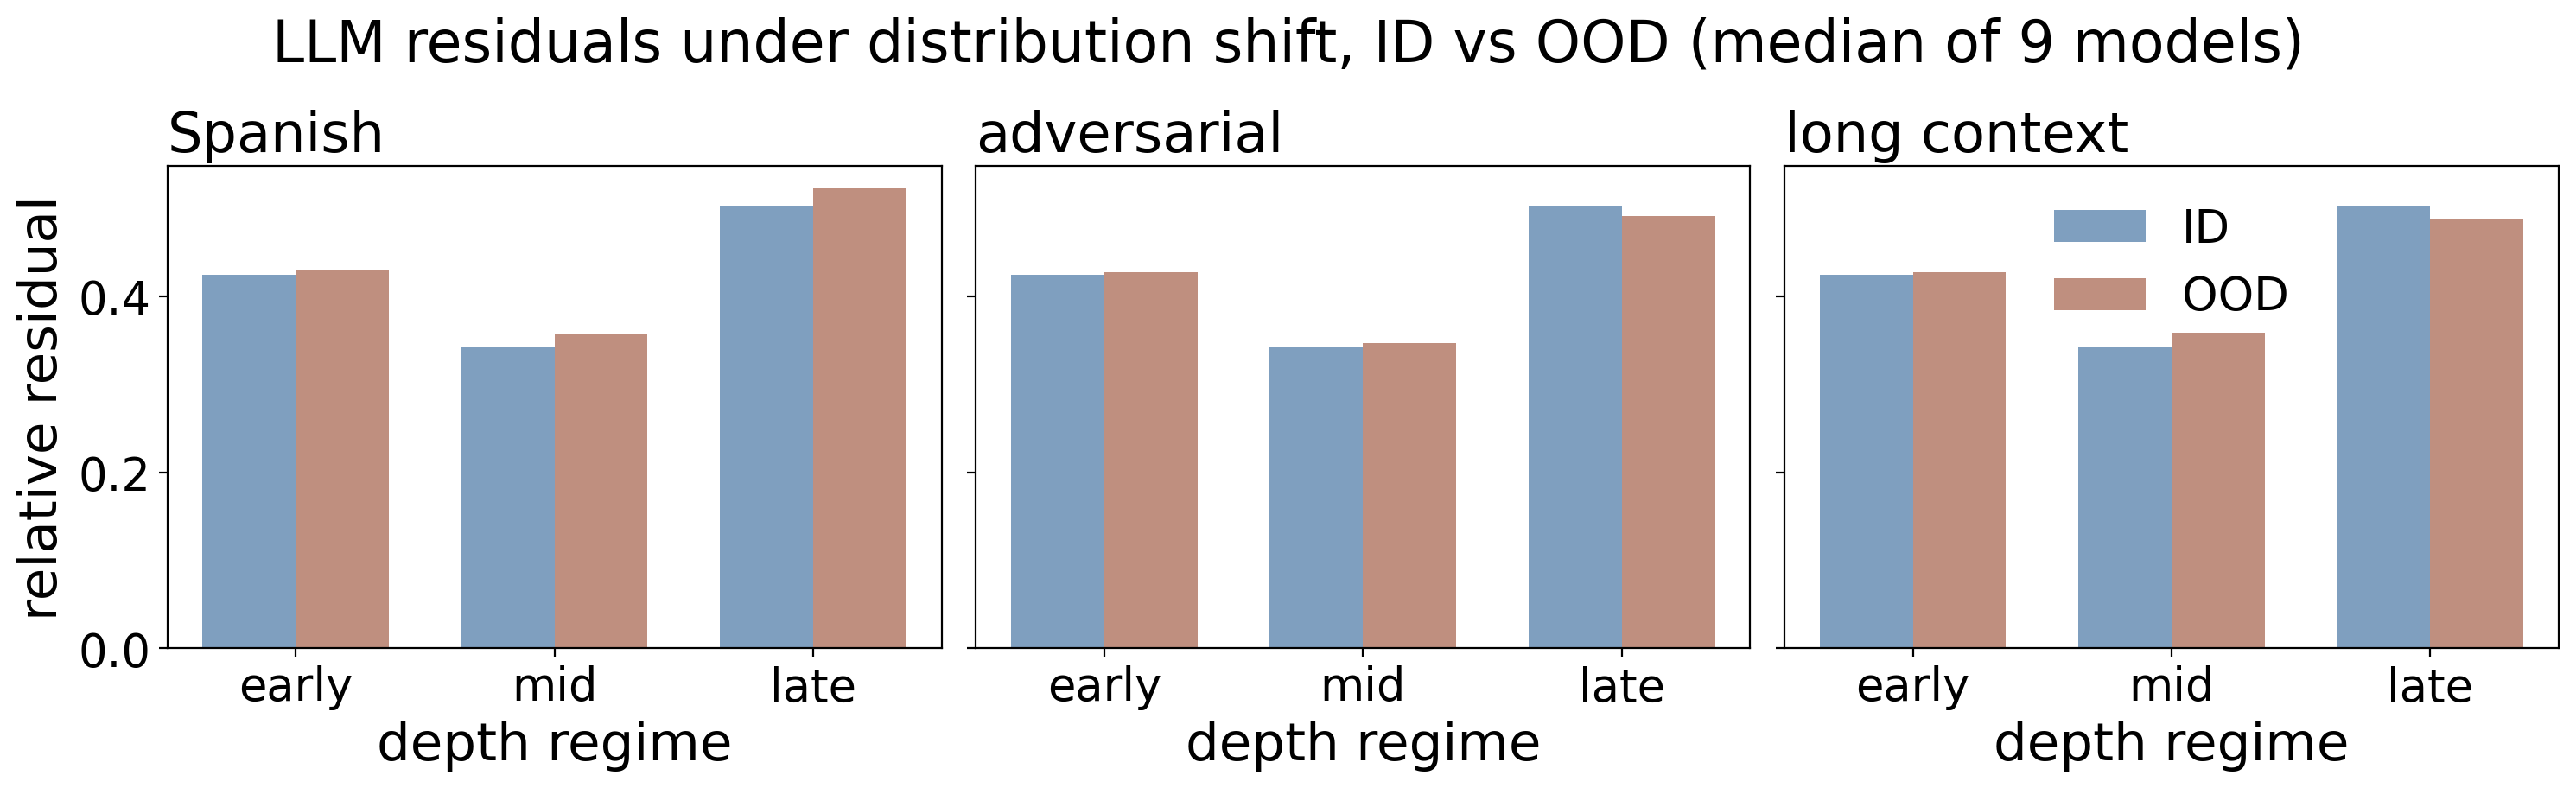

In [2]:
# ---------- Panel D: residuals under distribution shift, ID vs OOD ----------
# Median across the 9 checkpoints of the relative residual per depth regime.
panelD = (llm.groupby(["shift", "regime"], observed=True)[["ID", "OOD", "amplification"]]
          .median().reset_index())
panelD.to_csv(RESULTS_DIR / "final_llm_panelD_id_vs_ood.csv", index=False)
display(panelD.round(4))

fig, axes_D = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax_D, (shift_, sub) in zip(axes_D, panelD.groupby("shift", observed=True)):
    sub = sub.set_index("regime").loc[REGIMES]
    xD = np.arange(len(REGIMES)); wD = 0.36
    ax_D.bar(xD - wD/2, sub["ID"], wD, color=COLOR_ID, label="ID")
    ax_D.bar(xD + wD/2, sub["OOD"], wD, color=COLOR_OOD, label="OOD")
    ax_D.set_xticks(xD, REGIMES, fontsize=19)
    ax_D.set_xlabel("depth regime", fontsize=22)
    ax_D.set_title(shift_, loc="left", fontsize=23)
    ax_D.tick_params(labelsize=19)
axes_D[0].set_ylabel("relative residual", fontsize=22)
axes_D[2].legend(fontsize=19, frameon=False)
fig.suptitle("LLM residuals under distribution shift, ID vs OOD (median of 9 models)", fontsize=24)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"final_llm_panelD_id_vs_ood.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "final_llm_panelD_id_vs_ood.png")
plt.close(fig)
display(IPyImage(str(FIG_DIR / "final_llm_panelD_id_vs_ood.png"), width=500))

**Panel D — LLM residuals under distribution shift (median across 9 checkpoints, DistilGPT-2 → Qwen-2.5-14B).** Relative residual (residual-block update norm / output-state norm) per depth regime, for within-distribution prompts (ID) vs three handcrafted shifts (OOD). The OOD amplification is real but *small* (typically +0.01–0.03 on baselines of 0.2–0.5) and clearest for the Spanish shift in mid/late depth — qualitatively parallel to (but not the same quantity as) the neural finding that residuals grow modestly, not catastrophically, under domain shift. Descriptive medians; no inferential test.

regime,early,mid,late
label,,,
DistilGPT-2,-0.0069,-0.0063,-0.0221
GPT-2 Small,0.0015,-0.0026,-0.0199
GPT-2 Medium,0.0056,-0.0000,-0.0439
Qwen 0.5B,-0.0167,0.0410,0.0110
GPT-2 Large,-0.0019,0.0029,0.0816
Qwen 1.5B,0.0232,0.0286,0.0035
Qwen 3B,0.0036,0.0165,0.0240
Qwen 7B,-0.0012,0.0001,0.0128
Qwen 14B,0.0006,0.0113,-0.0026


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/final_llm_panelE_long_context.png


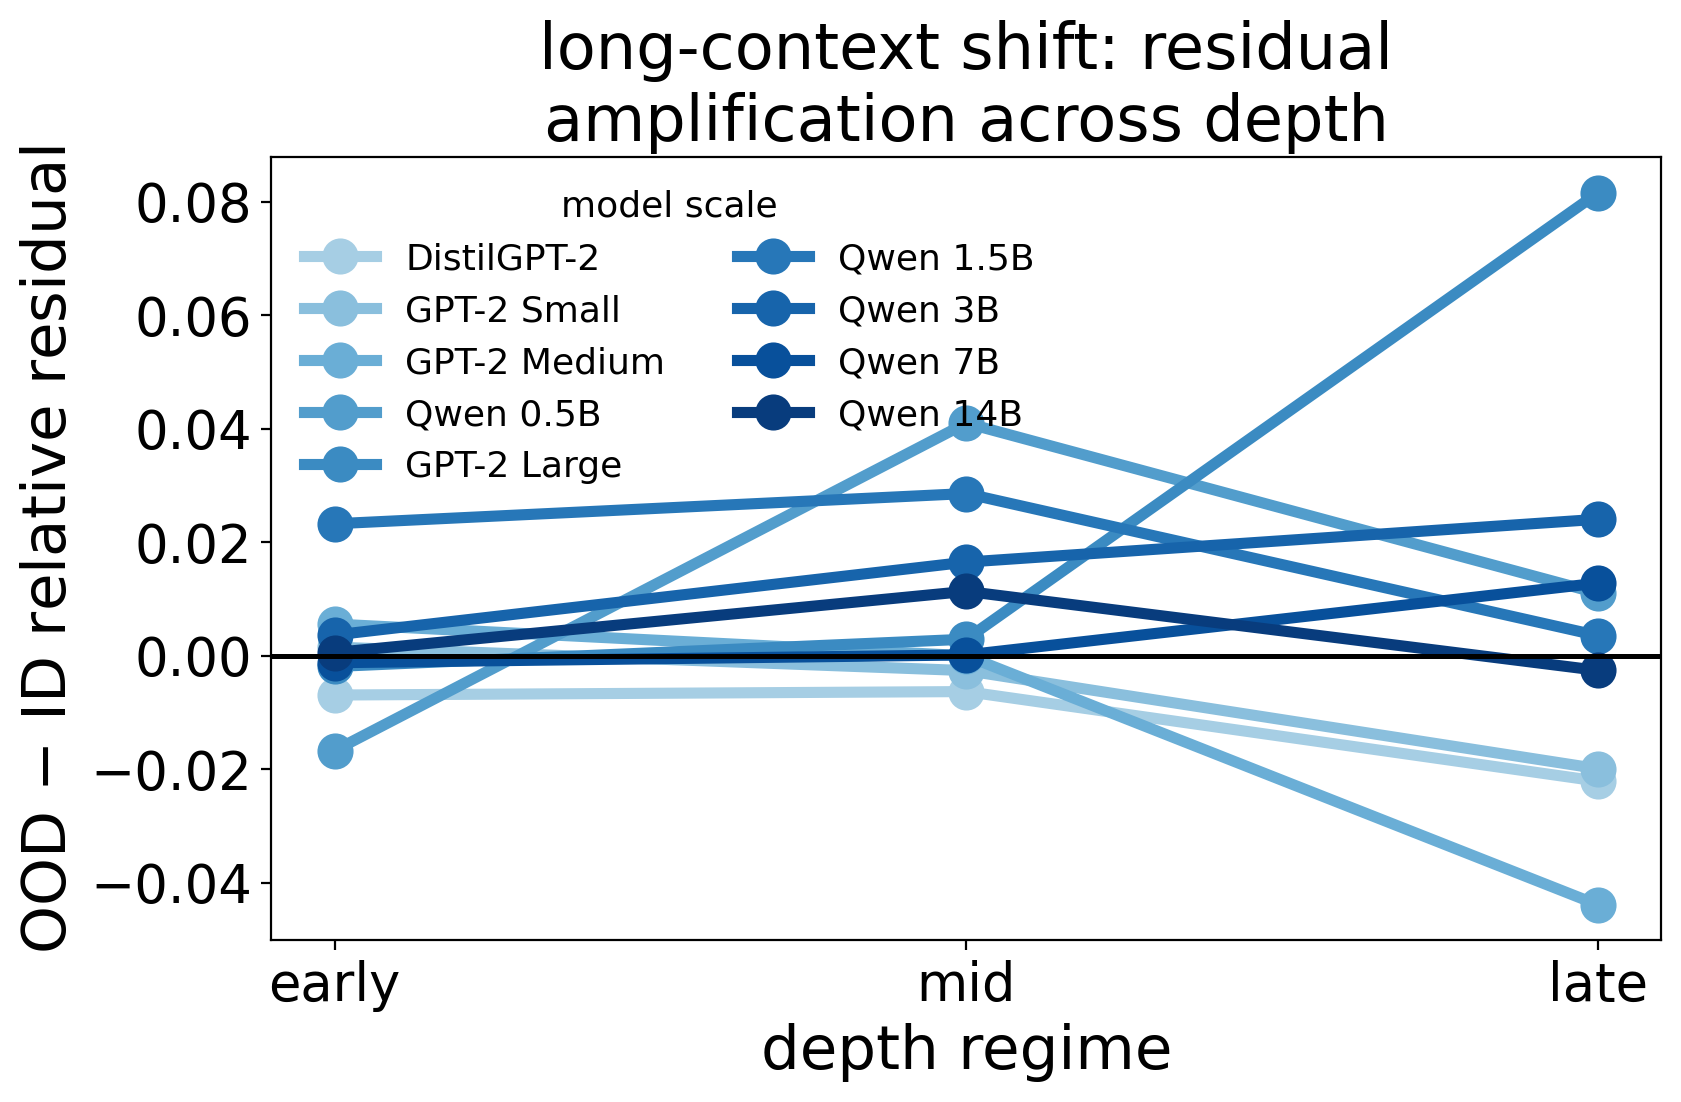

In [3]:
# ---------- Panel E: long-context shift — OOD amplification across depth, by model scale ----------
ctx = llm[llm["shift"] == "long context"].copy()
ctx = ctx.sort_values("params")
panelE = ctx.pivot(index="label", columns="regime", values="amplification")
panelE = panelE.loc[ctx.drop_duplicates("label")["label"]]      # keep scale order
panelE.to_csv(RESULTS_DIR / "final_llm_panelE_long_context_amplification.csv")
display(panelE.round(4))

# scale-shaded blues: small models light, large models dark (analog of context-length shades)
labels_E = panelE.index.tolist()
shades_E = plt.cm.Blues(np.linspace(0.35, 0.95, len(labels_E)))
fig, axE = plt.subplots(figsize=(8.5, 5.6))
xE = np.arange(len(REGIMES))
for lab_, colE in zip(labels_E, shades_E):
    axE.plot(xE, panelE.loc[lab_, REGIMES], "o-", color=colE, lw=4, ms=12, label=lab_)
axE.axhline(0, color="k", lw=1.8)
axE.set_xticks(xE, REGIMES, fontsize=19)
axE.set_xlabel("depth regime", fontsize=22)
axE.set_ylabel("OOD $-$ ID relative residual", fontsize=22)
axE.tick_params(labelsize=19)
axE.legend(fontsize=13, frameon=False, ncols=2, title="model scale", title_fontsize=13)
axE.set_title("long-context shift: residual\namplification across depth", fontsize=23)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"final_llm_panelE_long_context.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "final_llm_panelE_long_context.png")
plt.close(fig)
display(IPyImage(str(FIG_DIR / "final_llm_panelE_long_context.png"), width=280))

**Panel E — long-context shift: residual amplification across depth, by model scale.** OOD − ID relative residual for the long-context prompt family, one line per checkpoint (light → dark = small → large). Amplification concentrates in mid/late depth and is heterogeneous across scales (Qwen models amplify in mid depth, up to +0.04; GPT-2 Medium/Small *shrink* late-layer residuals under long context). This panel is *not* the analog of the neural context panel (context there is a regressor in a fitted model; here it is an input property), and the direction differs: in the brain, longer context reduced short-horizon residuals; here, long-context *inputs* mildly inflate residual updates in the depth range where context is integrated.

regime,label,family,params,early,mid,late
0,DistilGPT-2,gpt2,81912576,0.624,0.404,0.794
3,GPT-2 Small,gpt2,124439808,0.368,0.256,0.515
2,GPT-2 Medium,gpt2,354823168,0.230,0.174,0.533
4,Qwen 0.5B,qwen,494032768,0.509,0.371,0.402
1,GPT-2 Large,gpt2,774030080,0.243,0.190,1.628
5,Qwen 1.5B,qwen,1543714304,0.484,0.350,0.437
7,Qwen 3B,qwen,3085938688,0.424,0.343,0.431
8,Qwen 7B,qwen,7615616512,0.498,0.381,0.503
6,Qwen 14B,qwen,14770033664,0.351,0.334,0.486


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/final_llm_panelF_network_size.png


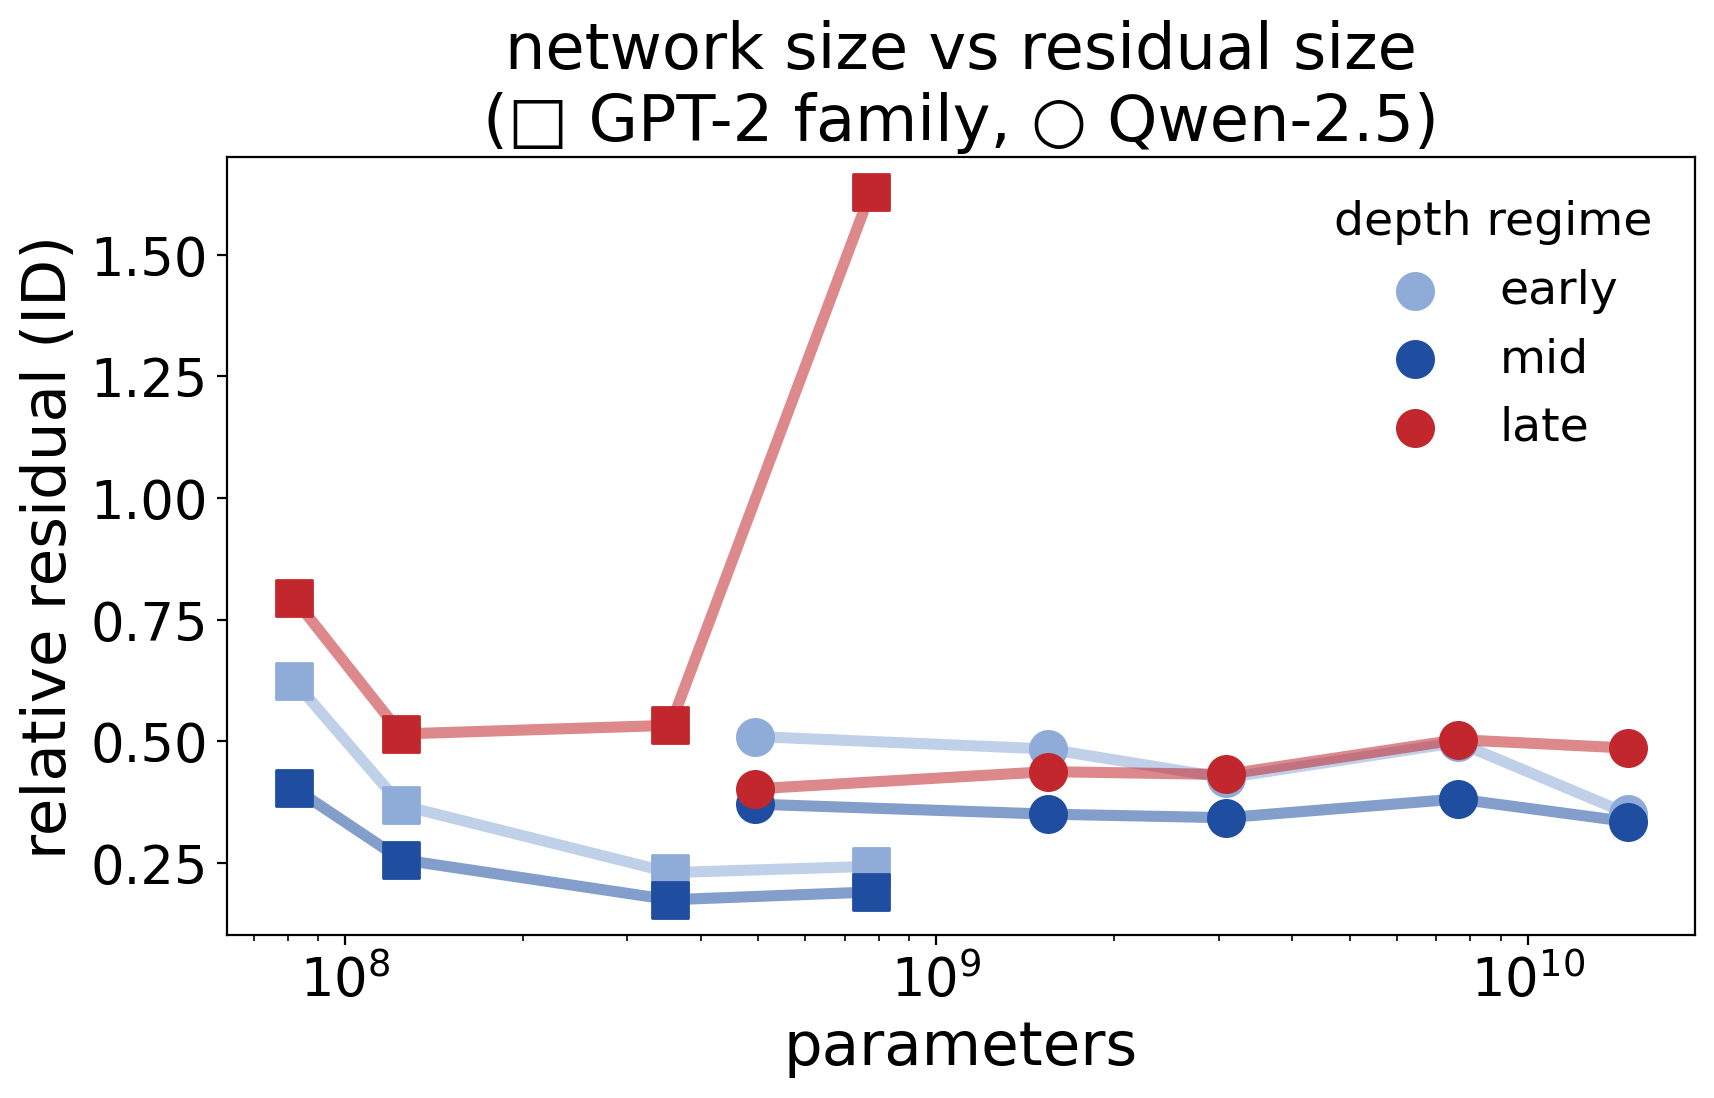

In [4]:
# ---------- Panel F: network size vs residual size ----------
# ID relative residual vs parameter count (log x), one line per depth regime.
# Shift family is irrelevant for ID values (same within-distribution prompts) -> use one.
base = llm[llm["shift"] == "long context"].pivot(index=["label", "family", "params"],
                                                 columns="regime", values="ID").reset_index()
base = base.sort_values("params")
base.to_csv(RESULTS_DIR / "final_llm_panelF_network_size.csv", index=False)
display(base.round(3))

REGIME_COLORS = {"early": "#8fabd8", "mid": COLOR_LINEAR, "late": "#c1272d"}
FAMILY_MARKERS = {"gpt2": "s", "qwen": "o"}
fig, axF = plt.subplots(figsize=(8.5, 5.6))
for regime in REGIMES:
    for fam_, mk_ in FAMILY_MARKERS.items():
        sub = base[base.family == fam_].sort_values("params")
        axF.plot(sub["params"], sub[regime], "-", color=REGIME_COLORS[regime], lw=4,
                 alpha=0.55, zorder=2)
        axF.scatter(sub["params"], sub[regime], s=170, marker=mk_,
                    color=REGIME_COLORS[regime], zorder=3,
                    label=regime if fam_ == "qwen" else None)
axF.set_xscale("log")
axF.set_xlabel("parameters", fontsize=22)
axF.set_ylabel("relative residual (ID)", fontsize=22)
axF.tick_params(labelsize=19)
axF.legend(fontsize=17, frameon=False, title="depth regime", title_fontsize=17)
axF.set_title("network size vs residual size\n(□ GPT-2 family, ○ Qwen-2.5)", fontsize=23)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"final_llm_panelF_network_size.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "final_llm_panelF_network_size.png")
plt.close(fig)
display(IPyImage(str(FIG_DIR / "final_llm_panelF_network_size.png"), width=280))

**Panel F — network size vs residual size (ID prompts, 82M → 14.8B parameters).** Relative residual per depth regime vs parameter count (log scale). Within the GPT-2 family, early/mid residuals *shrink* with scale (0.62 → 0.24 early, DistilGPT-2 → Large); across the Qwen-2.5 family they drift down more gently (0.51 → 0.35 early) — consistent with a bounded, slowly saturating residual budget at scale, qualitatively parallel to the neural saturating trend (though "size" here means parameters, not observed state dimension). Honest caveats: late-depth residuals do not shrink monotonically (GPT-2 Large's final layers are an outlier at 1.6, off-trend), and the two families are not directly comparable in absolute value (different architectures and tokenizers); read within-family trends only.